# **`Import the Libraries and Load the Dataset`**

In [1]:
# Import libraries #
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

#Display plots inside the notebook
%matplotlib inline

In [2]:
from google.colab import files

uploaded = files.upload()

Saving bank.csv to bank.csv


# **Inspect the Dataset**

In [19]:
df = pd.read_csv("bank.csv")

In [12]:
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes


In [13]:
df.tail()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no
11161,34,technician,married,secondary,no,0,no,no,cellular,9,jul,628,1,-1,0,unknown,no


In [14]:
df.shape

(11162, 17)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11162 entries, 0 to 11161
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        11162 non-null  int64 
 1   job        11162 non-null  object
 2   marital    11162 non-null  object
 3   education  11162 non-null  object
 4   default    11162 non-null  object
 5   balance    11162 non-null  int64 
 6   housing    11162 non-null  object
 7   loan       11162 non-null  object
 8   contact    11162 non-null  object
 9   day        11162 non-null  int64 
 10  month      11162 non-null  object
 11  duration   11162 non-null  int64 
 12  campaign   11162 non-null  int64 
 13  pdays      11162 non-null  int64 
 14  previous   11162 non-null  int64 
 15  poutcome   11162 non-null  object
 16  deposit    11162 non-null  object
dtypes: int64(7), object(10)
memory usage: 1.4+ MB


The dataset consists of 11,162 customer records and 17 variables. Inspection using df.info() showed that all variables contain 11,162 non-null values, indicating there are no missing (null) values in the dataset. The dataset contains 7 numerical variables and 10 categorical variables, making it suitable for both descriptive analysis and predictive modeling. No null values were detected.

In [18]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


# **Data Cleaning**

**Check for missing value**

In [21]:
df.isnull().sum()

,0
age,0
job,0
marital,0
education,0
default,0
balance,0
housing,0
loan,0
contact,0
day,0


**Check for duplicate**

In [22]:
df.duplicated().sum()

np.int64(0)

**Check the categorical data**

In [41]:
print(df['job'].value_counts())

print(df['education'].value_counts())

print(df['contact'].value_counts())

print(df['poutcome'].value_counts())

print(df.describe(include='object'))

job
management       2566
blue-collar      1944
technician       1823
admin.           1334
services          923
retired           778
self-employed     405
student           360
unemployed        357
entrepreneur      328
housemaid         274
unknown            70
Name: count, dtype: int64
education
secondary    5476
tertiary     3689
primary      1500
unknown       497
Name: count, dtype: int64
contact
cellular     8042
unknown      2346
telephone     774
Name: count, dtype: int64
poutcome
unknown    8326
failure    1228
success    1071
other       537
Name: count, dtype: int64
               job  marital  education default housing   loan   contact  \
count        11162    11162      11162   11162   11162  11162     11162   
unique          12        3          4       2       2      2         3   
top     management  married  secondary      no      no     no  cellular   
freq          2566     6351       5476   10994    5881   9702      8042   

        month poutcome deposit  
co

**Understand the numerical variables using descriptive statistics.**

In [29]:
df.describe()

,age,balance,day,duration,campaign,pdays,previous
count,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000,11162.000000
mean,41.231948,1528.538524,15.658036,371.993818,2.508421,51.330407,0.832557
std,11.913369,3225.413326,8.420740,347.128386,2.722077,108.758282,2.292007
min,18.000000,-6847.000000,1.000000,2.000000,1.000000,-1.000000,0.000000
25%,32.000000,122.000000,8.000000,138.000000,1.000000,-1.000000,0.000000
50%,39.000000,550.000000,15.000000,255.000000,2.000000,-1.000000,0.000000
75%,49.000000,1708.000000,22.000000,496.000000,3.000000,20.750000,1.000000
max,95.000000,81204.000000,31.000000,3881.000000,63.000000,854.000000,58.000000


# **Exploratory Data Analysis (EDA).**

**Understand the Target Variable**

How many customers subscribed to the Fixed Deposit, and how many did not?

/tmp/ipykernel_433/3556915145.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(


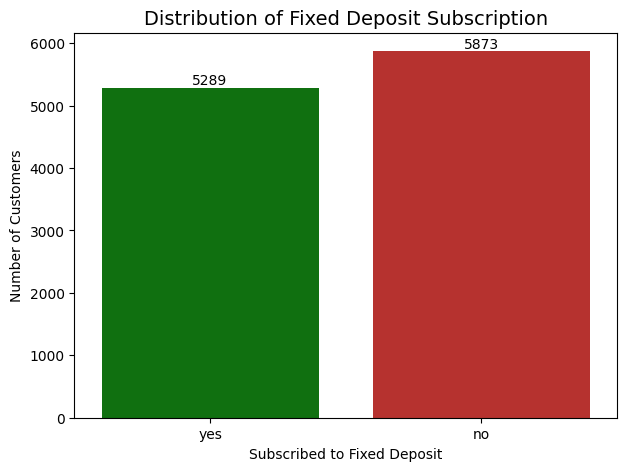

In [22]:
plt.figure(figsize=(7,5))

ax = sns.countplot(
    x='deposit',
    data=df,
    palette=['#008000', '#CD1C18']
)

plt.title('Distribution of Fixed Deposit Subscription', fontsize=14)
plt.xlabel('Subscribed to Fixed Deposit')
plt.ylabel('Number of Customers')

# Add values on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.show()

**Age Distribution**

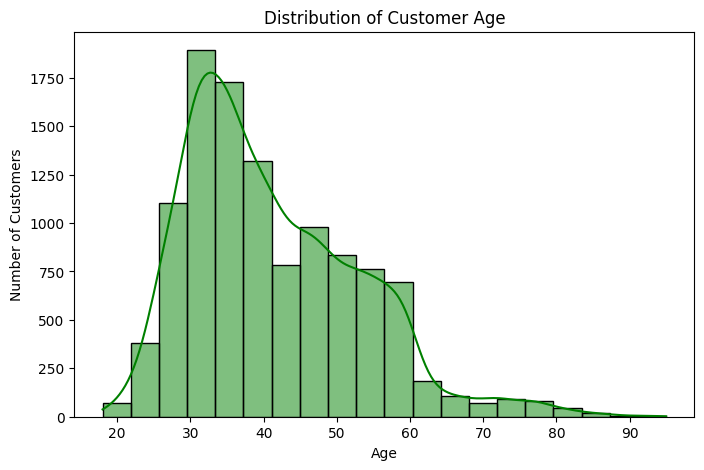

In [23]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='age',
    bins=20,
    kde=True,
    color='#008000'
)

plt.title('Distribution of Customer Age')
plt.xlabel('Age')
plt.ylabel('Number of Customers')

plt.show()

**Account Balance** **Distribution**

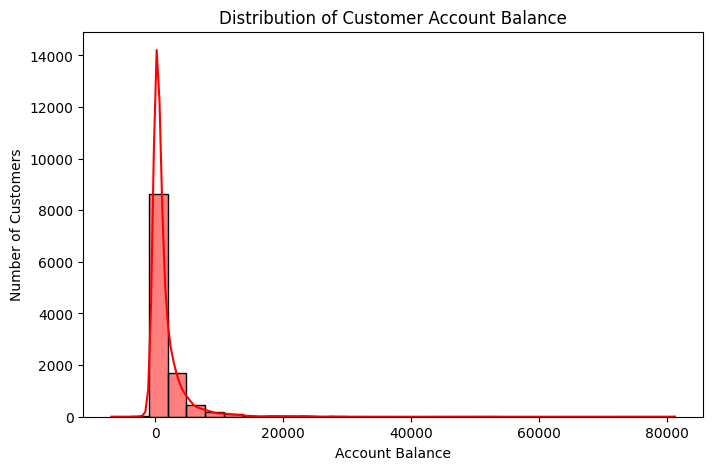

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x='balance',
    bins=30,
    kde=True,
    color='red'
)

plt.title('Distribution of Customer Account Balance')
plt.xlabel('Account Balance')
plt.ylabel('Number of Customers')

plt.show()

**Job vs Fixed Deposit Subscription**

Does a customer's occupation influence whether they subscribe to a fixed deposit?

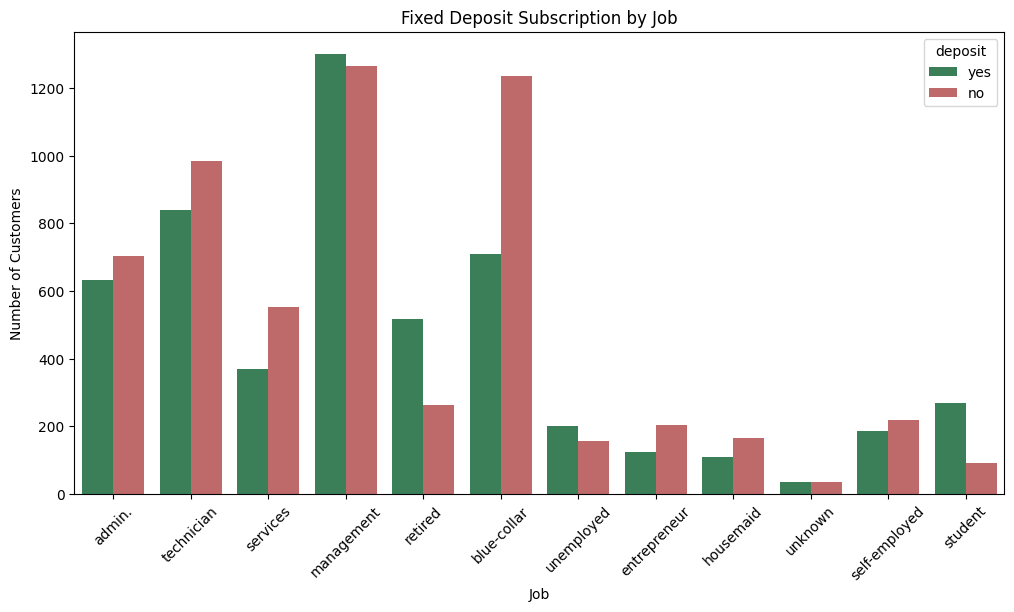

In [25]:
plt.figure(figsize=(12,6))

sns.countplot(
    data=df,
    x='job',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Job')
plt.xlabel('Job')
plt.ylabel('Number of Customers')

plt.xticks(rotation=45)

plt.show()

In [26]:
job = (
    df
    .groupby('job')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

job_yes = job[job['deposit'] == 'yes']

job_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

,job,deposit,Subscription Rate (%)
0,student,yes,74.722222
1,retired,yes,66.323907
2,unemployed,yes,56.582633
3,management,yes,50.701481
4,unknown,yes,48.571429
5,admin.,yes,47.301349
6,self-employed,yes,46.172840
7,technician,yes,46.077894
8,services,yes,39.978332
9,housemaid,yes,39.781022


**Marital Status vs Fixed Deposit Subscription**

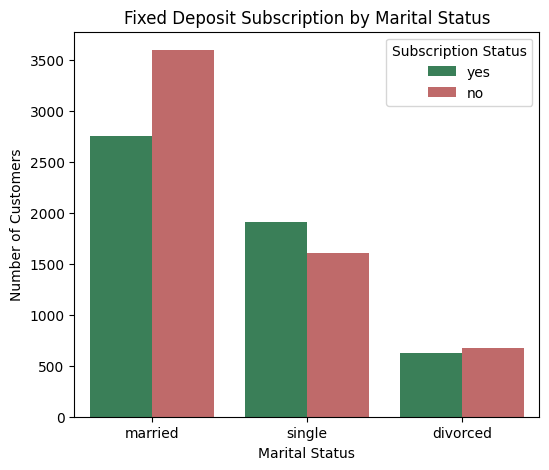

In [27]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='marital',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Number of Customers')

plt.legend(title='Subscription Status')

plt.show()

Subscription Rate (%)

In [28]:
marital = (
    df
    .groupby('marital')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

marital_yes = marital[marital['deposit'] == 'yes']

marital_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

,marital,deposit,Subscription Rate (%)
0,single,yes,54.349062
1,divorced,yes,48.105182
2,married,yes,43.378995


**Housing loan vs subscription**

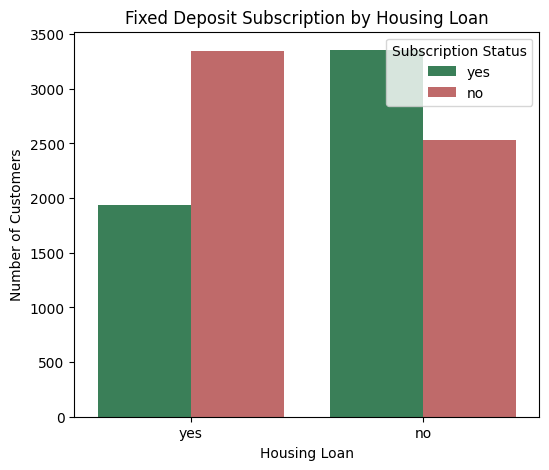

In [29]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='housing',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Number of Customers')

plt.legend(title='Subscription Status')

plt.show()

In [30]:
housing = (
    df
    .groupby('housing')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

housing_yes = housing[housing['deposit'] == 'yes']

housing_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

,housing,deposit,Subscription Rate (%)
0,no,yes,57.031117
1,yes,yes,36.640788


**Education vs Fixed Deposit Subscription**

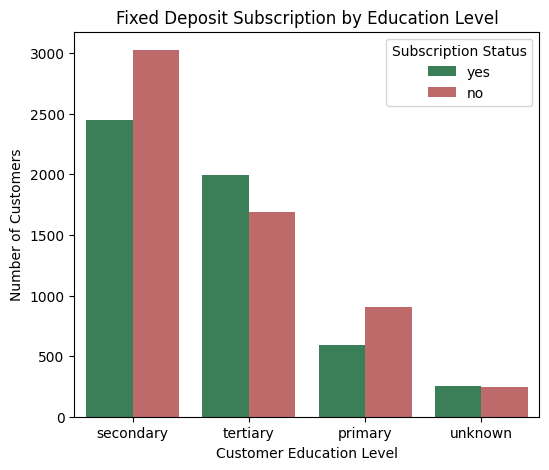

In [31]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='education',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Education Level')
plt.xlabel('Customer Education Level')
plt.ylabel('Number of Customers')

plt.legend(title='Subscription Status')

plt.show()

In [32]:
education = (
    df
    .groupby('education')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

education_yes = education[education['deposit'] == 'yes']

education_yes = education_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

education_yes

,education,deposit,Subscription Rate (%)
0,tertiary,yes,54.106804
1,unknown,yes,50.704225
2,secondary,yes,44.740687
3,primary,yes,39.400000


**Housing Loan vs Fixed Deposit**

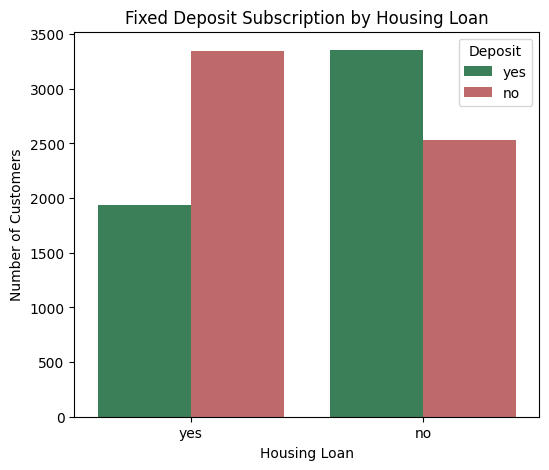

In [35]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='housing',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Housing Loan')
plt.xlabel('Housing Loan')
plt.ylabel('Number of Customers')

plt.legend(title='Deposit')

plt.show()

In [36]:
housing = (
    df
    .groupby('housing')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

housing_yes = housing[housing['deposit'] == 'yes']

housing_yes = housing_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

housing_yes

,housing,deposit,Subscription Rate (%)
0,no,yes,57.031117
1,yes,yes,36.640788


Personal loan

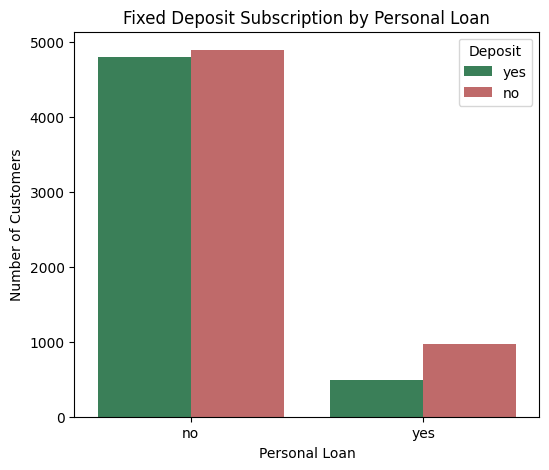

In [37]:
plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x='loan',
    hue='deposit',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Fixed Deposit Subscription by Personal Loan')
plt.xlabel('Personal Loan')
plt.ylabel('Number of Customers')

plt.legend(title='Deposit')

plt.show()

In [38]:
loan = (
    df
    .groupby('loan')['deposit']
    .value_counts(normalize=True)
    .mul(100)
    .rename('Subscription Rate (%)')
    .reset_index()
)

loan_yes = loan [loan['deposit'] == 'yes']

loan_yes = loan_yes.sort_values(
    'Subscription Rate (%)',
    ascending=False
).reset_index(drop=True)

loan_yes

,loan,deposit,Subscription Rate (%)
0,no,yes,49.525871
1,yes,yes,33.150685


**Previous Campaign Outcome vs Fixed Deposit Subscription**

Does the outcome of a previous marketing campaign influence whether a customer subscribes to a fixed deposit?

In [50]:
poutcome_rate = pd.crosstab(
    df['poutcome'],
    df['deposit'],
    normalize='index'
) * 100

poutcome_rate.round(2)

deposit,no,yes
poutcome,,
failure,49.67,50.33
other,42.83,57.17
success,8.68,91.32
unknown,59.33,40.67


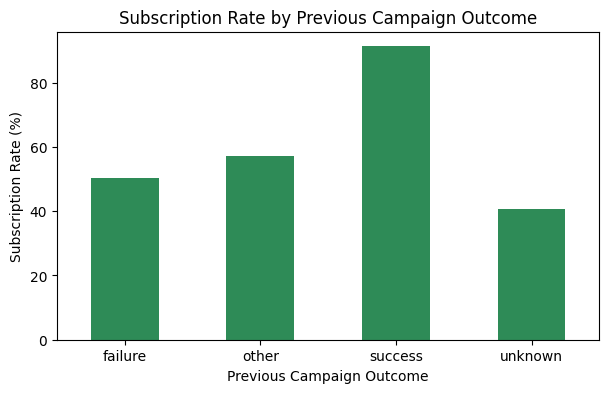

In [52]:
poutcome_rate['yes'].plot(
    kind='bar',
    figsize=(7,4),
    color='#2E8B57'
)

plt.title('Subscription Rate by Previous Campaign Outcome')
plt.xlabel('Previous Campaign Outcome')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

**Contact Method vs Fixed Deposit**

Does the method used to contact a customer influence their likelihood of subscribing to a fixed deposit?

In [54]:
contact_rate = pd.crosstab(
    df['contact'],
    df['deposit'],
    normalize='index'
) * 100

contact_rate.round(2)

deposit,no,yes
contact,,
cellular,45.67,54.33
telephone,49.61,50.39
unknown,77.41,22.59


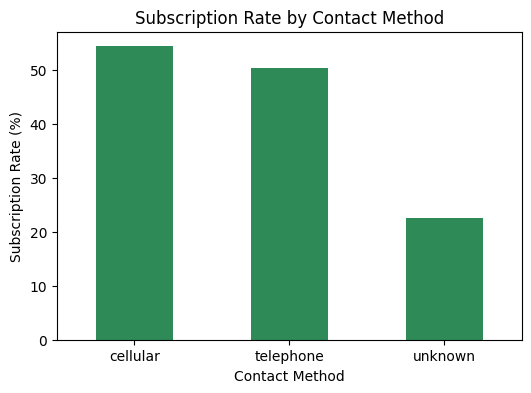

In [55]:
contact_rate['yes'].plot(
    kind='bar',
    figsize=(6,4),
    color='#2E8B57'
)

plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)

plt.show()

In [56]:
pd.crosstab(df['contact'], df['deposit'])

deposit,no,yes
contact,,
cellular,3673,4369
telephone,384,390
unknown,1816,530


**Compare Numerical Variables by Deposit Status**

Do customers who subscribed tend to be older or younger than those who did not subscribe?

<Axes: xlabel='deposit', ylabel='age'>

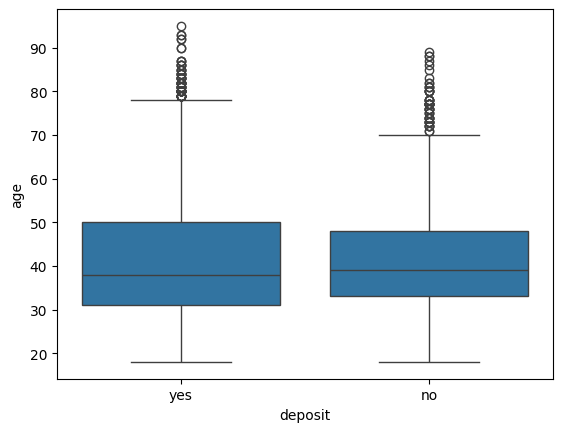

In [48]:
sns.boxplot(
    data=df,
    x='deposit',
    y='age'
)

<Axes: xlabel='deposit', ylabel='campaign'>

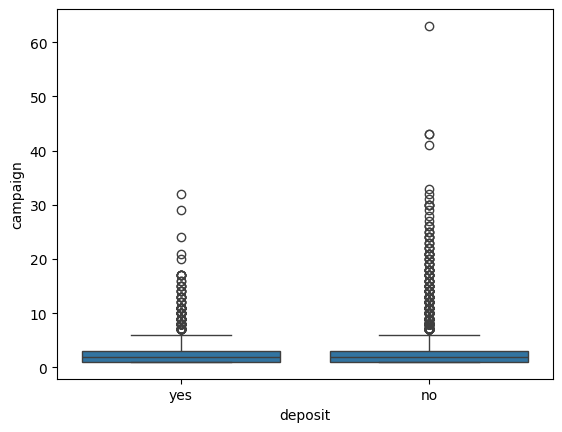

In [49]:
sns.boxplot(
    data=df,
    x='deposit',
    y='campaign'
)

<Axes: xlabel='deposit', ylabel='previous'>

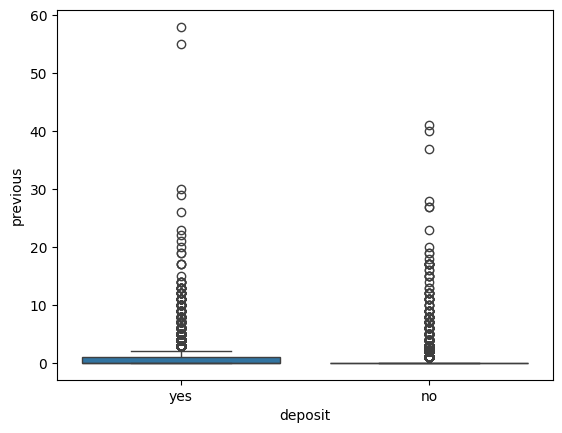

In [50]:
sns.boxplot(
    data=df,
    x='deposit',
    y='previous'
)

<Axes: xlabel='deposit', ylabel='pdays'>

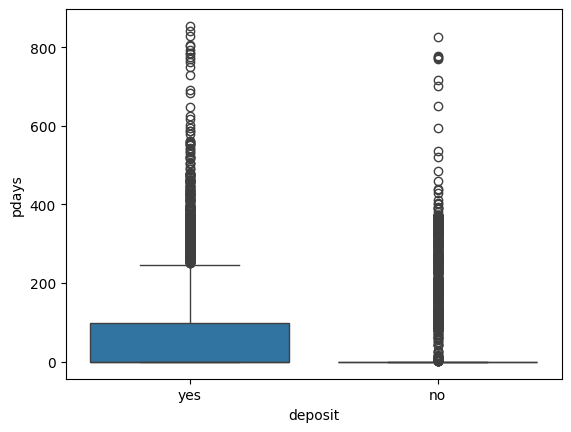

In [51]:
sns.boxplot(
    data=df,
    x='deposit',
    y='pdays'
)

<Axes: xlabel='deposit', ylabel='duration'>

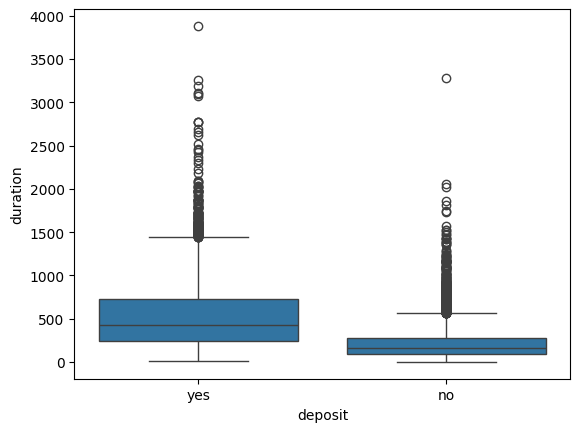

In [52]:
sns.boxplot(
    data=df,
    x='deposit',
    y='duration'
)

**Account Balance by Deposit Status (Box Plot)**

Do customers who subscribe to a fixed deposit generally have higher account balances than those who do not?

/tmp/ipykernel_433/2475121801.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


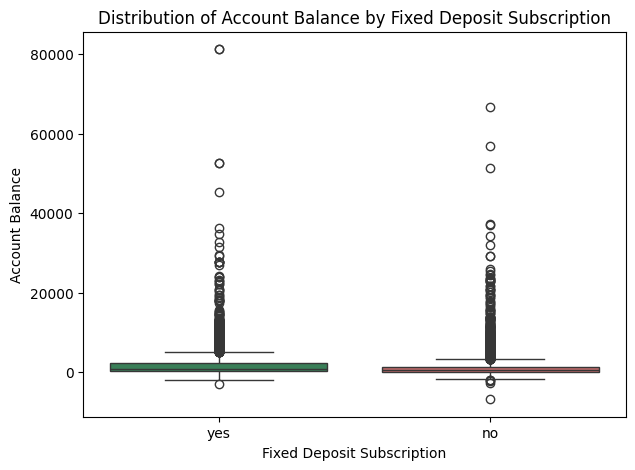

In [53]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='deposit',
    y='balance',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Distribution of Account Balance by Fixed Deposit Subscription')
plt.xlabel('Fixed Deposit Subscription')
plt.ylabel('Account Balance')

plt.show()

**Marketing Campaign Contacts (campaign) vs Fixed Deposit Subscription**

Does the number of times a customer is contacted during the current marketing campaign influence their likelihood of subscribing to a fixed deposit?

/tmp/ipykernel_433/823004390.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


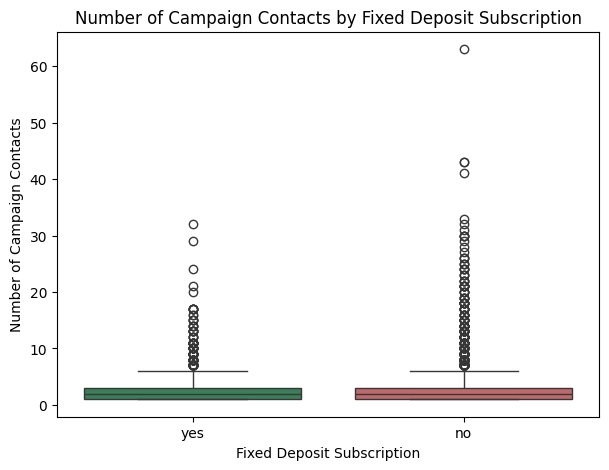

In [54]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='deposit',
    y='campaign',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Number of Campaign Contacts by Fixed Deposit Subscription')
plt.xlabel('Fixed Deposit Subscription')
plt.ylabel('Number of Campaign Contacts')

plt.show()

**Previous Contacts (previous) vs Fixed Deposit Subscription**

Does the number of previous contacts with a customer influence their likelihood of subscribing to a fixed deposit?

/tmp/ipykernel_433/2452922984.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


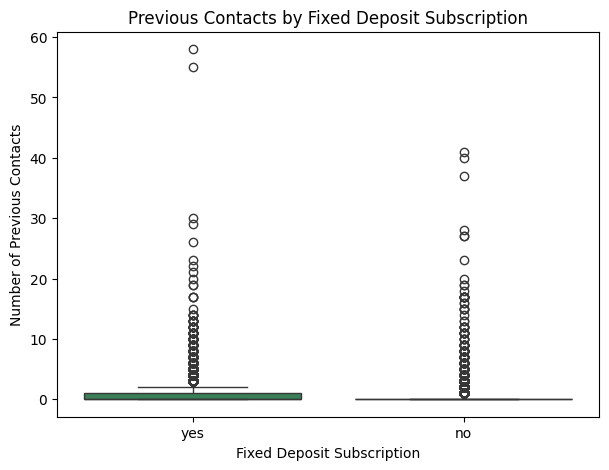

In [55]:
plt.figure(figsize=(7,5))

sns.boxplot(
    data=df,
    x='deposit',
    y='previous',
    palette=['#2E8B57', '#CD5C5C']
)

plt.title('Previous Contacts by Fixed Deposit Subscription')
plt.xlabel('Fixed Deposit Subscription')
plt.ylabel('Number of Previous Contacts')

plt.show()

# **Data Preparation for Machine Learning**

In [57]:
corr = df.select_dtypes(include='number').corr()

corr

,age,balance,day,duration,campaign,pdays,previous
age,1.000000,0.112300,-0.000762,0.000189,-0.005278,0.002774,0.020169
balance,0.112300,1.000000,0.010467,0.022436,-0.013894,0.017411,0.030805
day,-0.000762,0.010467,1.000000,-0.018511,0.137007,-0.077232,-0.058981
duration,0.000189,0.022436,-0.018511,1.000000,-0.041557,-0.027392,-0.026716
campaign,-0.005278,-0.013894,0.137007,-0.041557,1.000000,-0.102726,-0.049699
pdays,0.002774,0.017411,-0.077232,-0.027392,-0.102726,1.000000,0.507272
previous,0.020169,0.030805,-0.058981,-0.026716,-0.049699,0.507272,1.000000


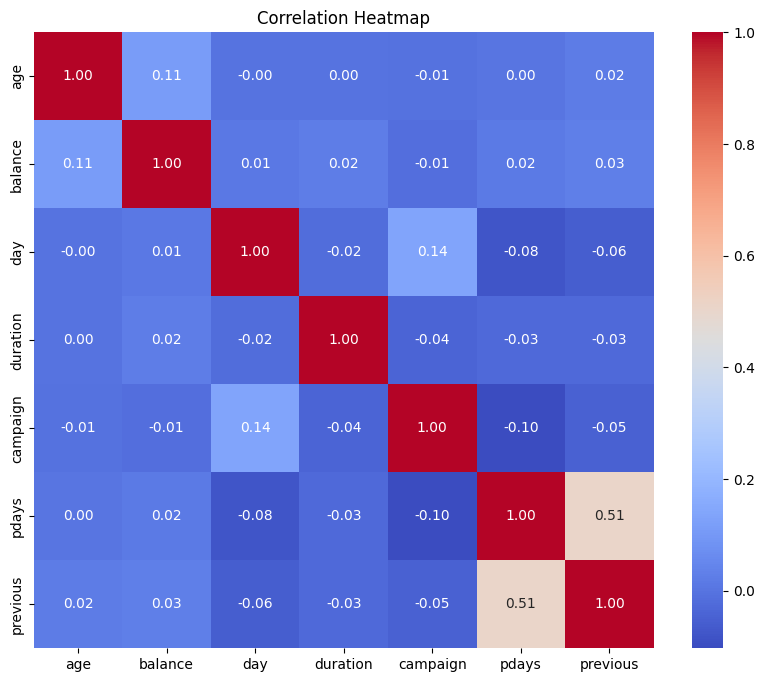

In [58]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Heatmap')

plt.show()

1. 0.507  → Moderate relationship
2. 0.137  → Weak relationship.
3. 0.112  → Weak relationship
4. 0.000  → No relationship.

Most variables are not strongly related to each other, except pdays and previous, which have a moderate positive relationship.

| Correlation | Meaning                         |
| ----------- | ------------------------------- |
| `+1`        | Move together perfectly         |
| `+0.5`      | Moderate relationship           |
| `+0.1`      | Very weak relationship          |
| `0`         | No relationship                 |
| `-0.1`      | Very weak opposite relationship |
| `-0.5`      | Moderate opposite relationship  |
| `-1`        | Perfect opposite movement       |


## **Feature Selection**

Which variables should our model use to predict whether a customer will subscribe to a fixed deposit?

**Remove duration**

In [60]:
df_ml = df.drop(columns=['duration'])

**Separate Features and Target**

In [61]:
X = df_ml.drop('deposit', axis=1)
y = df_ml['deposit']

**Encode the target variable (y)**

In [62]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

**Check categorical columns in X**

In [63]:
X.select_dtypes(include='object').columns

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'poutcome'],
      dtype='object')

**Encode categorical variables (X)**

In [64]:
X = pd.get_dummies(X, drop_first=True)

**Check if encoding worked (optional)**

In [65]:
X.shape

(11162, 41)

In [66]:
X.select_dtypes(include='object').columns

Index([], dtype='object')

**Train-Test Split**

In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

**Check Shapes (Optional)**

In [68]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Target:", y_train.shape)
print("Testing Target:", y_test.shape)

Training Features: (8929, 41)
Testing Features: (2233, 41)
Training Target: (8929,)
Testing Target: (2233,)


**Scale the data**

In [69]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# **Logistic Regression.**

**Import Logistic Regression**

In [70]:
from sklearn.linear_model import LogisticRegression

**Create the Model**

In [71]:
log_model = LogisticRegression(random_state=42)

**Train the Model**

In [72]:
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

**Make Predictions**

In [73]:
y_pred = log_model.predict(X_test_scaled)

**Evaluate the Model**

In [74]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.7133900582176445
[[981 185]
 [455 612]]
              precision    recall  f1-score   support

           0       0.68      0.84      0.75      1166
           1       0.77      0.57      0.66      1067

    accuracy                           0.71      2233
   macro avg       0.73      0.71      0.71      2233
weighted avg       0.72      0.71      0.71      2233



In [75]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 0.7133900582176445


**Import**

In [76]:
from sklearn.metrics import confusion_matrix

In [77]:
cm = confusion_matrix(y_test, y_pred)

**Heatmap**

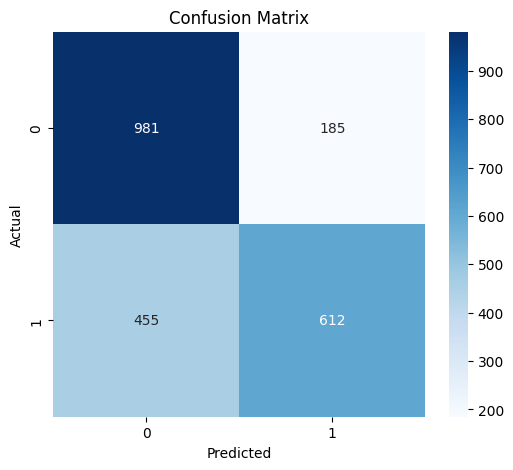

In [78]:
plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.show()

**Classification Report**

In [79]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.68      0.84      0.75      1166
           1       0.77      0.57      0.66      1067

    accuracy                           0.71      2233
   macro avg       0.73      0.71      0.71      2233
weighted avg       0.72      0.71      0.71      2233



**Interpret the coefficients**

In [82]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_model.coef_[0]
})

importance['Absolute'] = importance['Coefficient'].abs()

importance = importance.sort_values(
    by='Absolute',
    ascending=False
)

print(importance.head(10))

             Feature  Coefficient  Absolute
39  poutcome_success     0.618177  0.618177
26   contact_unknown    -0.512832  0.512832
27         month_aug    -0.265836  0.265836
35         month_nov    -0.235741  0.235741
31         month_jul    -0.207385  0.207385
33         month_mar     0.205126  0.205126
3           campaign    -0.204289  0.204289
34         month_may    -0.197920  0.197920
23       housing_yes    -0.191636  0.191636
30         month_jan    -0.186039  0.186039


**Plot the importance**

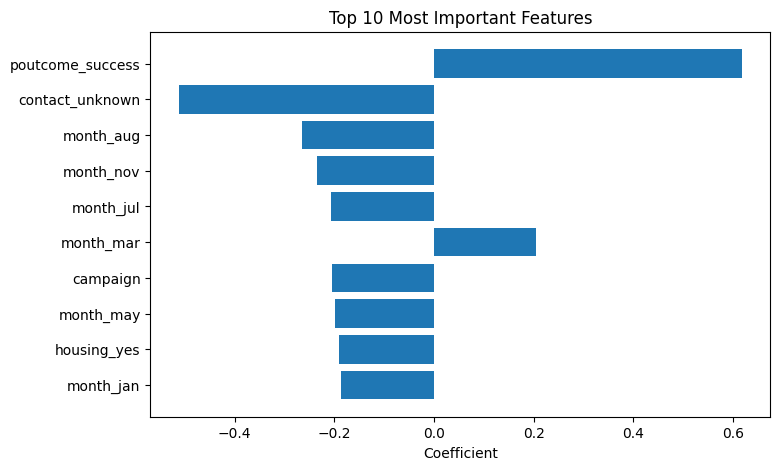

In [83]:
import matplotlib.pyplot as plt

top10 = importance.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10['Feature'], top10['Coefficient'])
plt.xlabel("Coefficient")
plt.title("Top 10 Most Important Features")
plt.gca().invert_yaxis()
plt.show()

# **Decision Tree Classifier 🌳**

**Import the model**

In [99]:
from sklearn.tree import DecisionTreeClassifier

**Create the model**

In [100]:
dt_model = DecisionTreeClassifier(random_state=42)

**Train the model**

In [101]:
dt_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

**Make Predictions**

In [102]:
y_pred_dt = dt_model.predict(X_test_scaled)

**Accuracy**

In [88]:
from sklearn.metrics import accuracy_score

print("Accuracy:",
      accuracy_score(y_test, y_pred_dt))

Accuracy: 0.6318853560232871


**Confusion Matrix**

In [98]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test,
                      y_pred_dt)

print(cm)

[[752 414]
 [408 659]]


**Classification Report**

In [104]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_dt
    )
)

              precision    recall  f1-score   support

           0       0.65      0.64      0.65      1166
           1       0.61      0.62      0.62      1067

    accuracy                           0.63      2233
   macro avg       0.63      0.63      0.63      2233
weighted avg       0.63      0.63      0.63      2233



**Check Feature Importance**

In [105]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    dt_model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,balance,0.201258
0,age,0.130032
2,day,0.121086
39,poutcome_success,0.081173
3,campaign,0.061680
26,contact_unknown,0.045251
4,pdays,0.039478
5,previous,0.020642
23,housing_yes,0.018956
19,education_secondary,0.016532


**Plot Feature Importance**

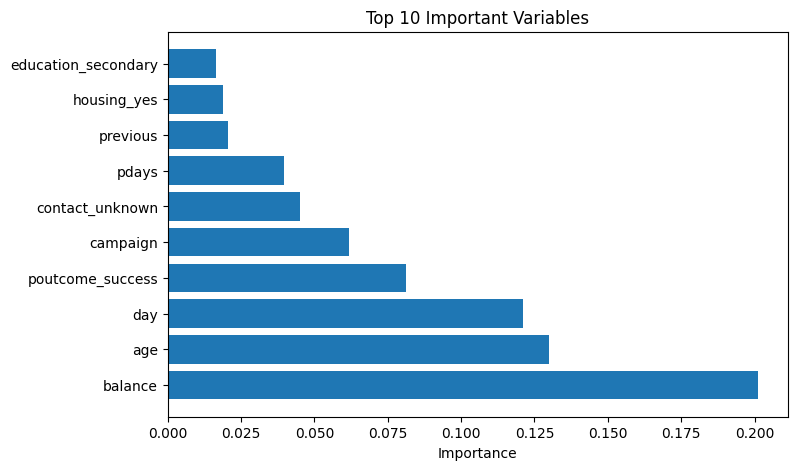

In [106]:
top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.title(
    'Top 10 Important Variables'
)

plt.xlabel('Importance')

plt.show()

**Visualize the Tree (Optional)**

In [95]:
from sklearn.tree import plot_tree

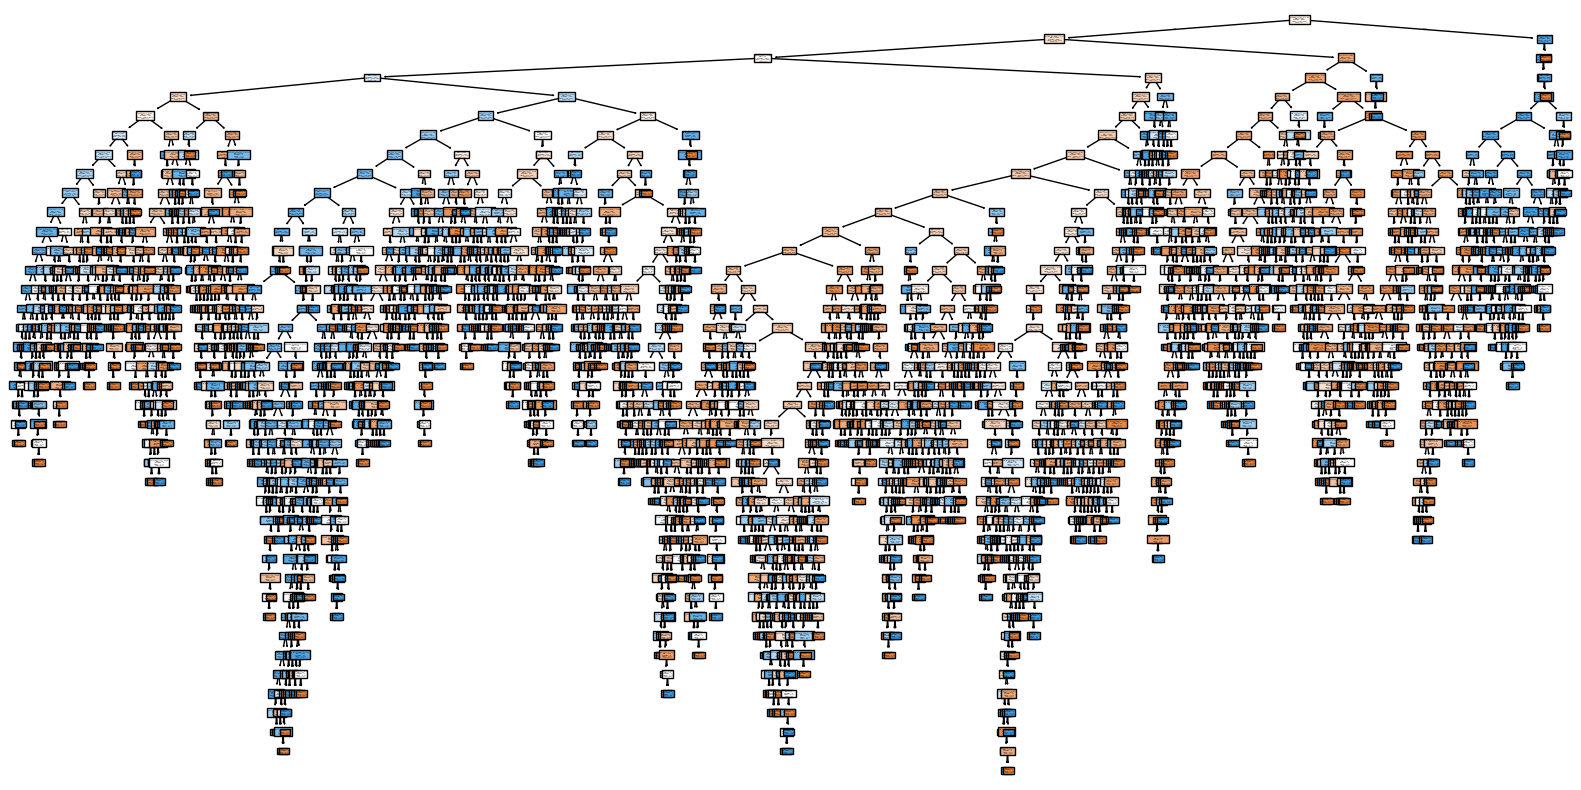

In [96]:
plt.figure(figsize=(20,10))

plot_tree(
    dt_model,
    filled=True,
    feature_names=X.columns,
    class_names=['No','Yes']
)

plt.show()

# **Random Forest 🌲**

**Import the Model**

In [111]:
from sklearn.ensemble import RandomForestClassifier

**Create the Model**

In [112]:
rf_model = RandomForestClassifier(
    random_state=42
)

In [113]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

**Train the Model**

In [114]:
rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

**Make Predictions**

In [115]:
y_pred_rf = rf_model.predict(X_test)

**Accuracy Score**

In [116]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(y_test, y_pred_rf)
)

Accuracy: 0.7344379758172862


**Confusion Matrix**

In [117]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_rf
)

print(cm)

[[955 211]
 [382 685]]


**Classification Report**

In [118]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_rf
    )
)

              precision    recall  f1-score   support

           0       0.71      0.82      0.76      1166
           1       0.76      0.64      0.70      1067

    accuracy                           0.73      2233
   macro avg       0.74      0.73      0.73      2233
weighted avg       0.74      0.73      0.73      2233



**Feature Importance ⭐**

In [119]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    rf_model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
1,balance,0.162300
0,age,0.143064
2,day,0.123765
3,campaign,0.068419
4,pdays,0.046033
26,contact_unknown,0.038707
39,poutcome_success,0.036663
23,housing_yes,0.028383
5,previous,0.025013
19,education_secondary,0.018567


**Plot Feature Importance (Optional)**

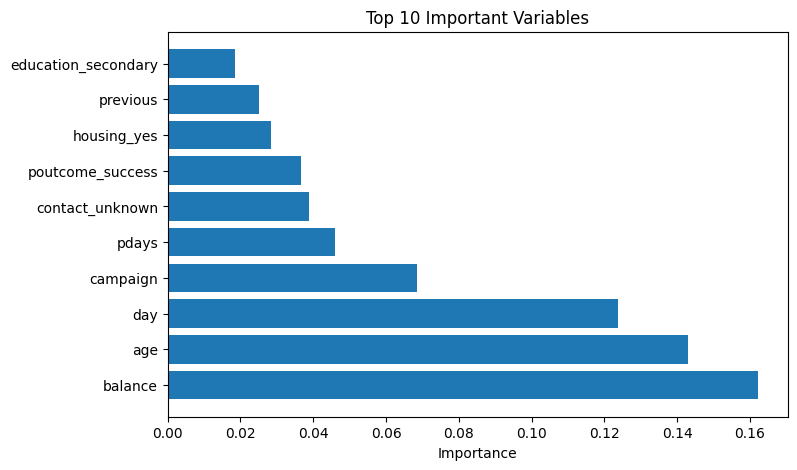

In [120]:
top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel('Importance')
plt.title('Top 10 Important Variables')

plt.show()

# **XGBoost 🚀**

**Install XGBoost (if not installed)**

In [121]:
!pip install xgboost

**Import XGBoost**

In [122]:
from xgboost import XGBClassifier

**Create the Model**

In [123]:
xgb_model = XGBClassifier(
    random_state=42
)

In [124]:
xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)

**Train the Model**

In [125]:
xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

**Make Predictions**

In [126]:
y_pred_xgb = xgb_model.predict(X_test)

**Accuracy Score**

In [127]:
from sklearn.metrics import accuracy_score

print(
    "Accuracy:",
    accuracy_score(
        y_test,
        y_pred_xgb
    )
)

Accuracy: 0.74205105239588


**Confusion Matrix**

In [128]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test,
    y_pred_xgb
)

print(cm)

[[999 167]
 [409 658]]


**Classification Report**

In [129]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        y_pred_xgb
    )
)

              precision    recall  f1-score   support

           0       0.71      0.86      0.78      1166
           1       0.80      0.62      0.70      1067

    accuracy                           0.74      2233
   macro avg       0.75      0.74      0.74      2233
weighted avg       0.75      0.74      0.74      2233



**Feature Importance**

In [130]:
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance':
    xgb_model.feature_importances_
})

importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

,Feature,Importance
39,poutcome_success,0.307426
26,contact_unknown,0.085877
33,month_mar,0.065836
32,month_jun,0.039304
23,housing_yes,0.037986
36,month_oct,0.037729
37,month_sep,0.035162
29,month_feb,0.029491
24,loan_yes,0.028028
27,month_aug,0.026672


**Plot Feature Importance (Optional)**

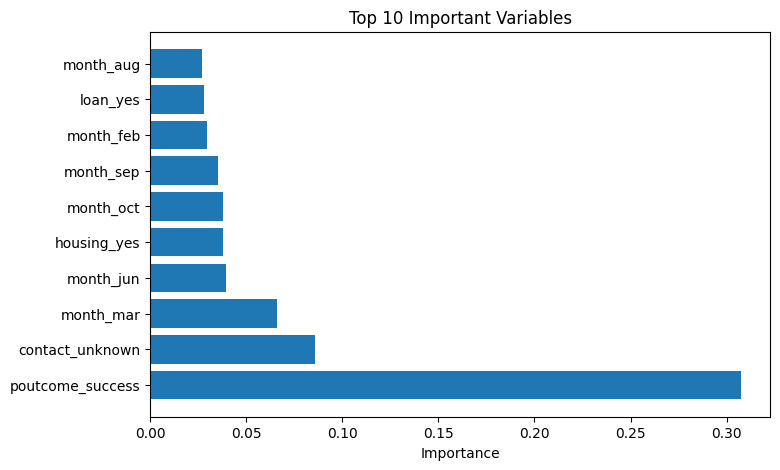

In [131]:
top10 = importance.sort_values(
    by='Importance',
    ascending=False
).head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel('Importance')
plt.title('Top 10 Important Variables')

plt.show()

# **Model Comparison**

**Logistic Regression**

In [132]:
log_accuracy = accuracy_score(y_test, y_pred)
print(log_accuracy)

0.7133900582176445


**Decision Tree**

In [134]:
dt_accuracy = accuracy_score(y_test, y_pred_dt)
print(dt_accuracy)

0.6780116435288849


**Random Forest**

In [135]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print(rf_accuracy)

0.7344379758172862


**XGBoost**

In [136]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
print(xgb_accuracy)

0.74205105239588


**Create a Comparison Table**

In [137]:
import pandas as pd

comparison = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    'Accuracy': [
        log_accuracy,
        dt_accuracy,
        rf_accuracy,
        xgb_accuracy
    ]
})

comparison

,Model,Accuracy
0,Logistic Regression,0.713390
1,Decision Tree,0.678012
2,Random Forest,0.734438
3,XGBoost,0.742051


**Sort from Best to Worst**

In [138]:
comparison = comparison.sort_values(
    by='Accuracy',
    ascending=False
)

comparison

,Model,Accuracy
3,XGBoost,0.742051
2,Random Forest,0.734438
0,Logistic Regression,0.713390
1,Decision Tree,0.678012


**Plot Comparison (Optional)**

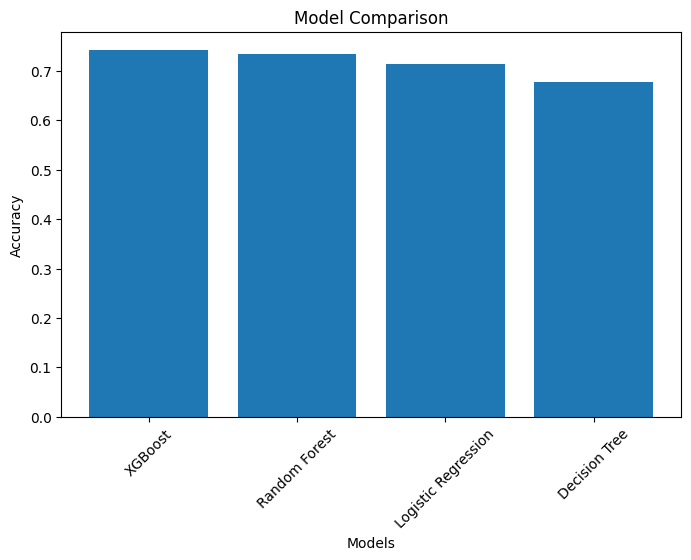

In [139]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Model'],
    comparison['Accuracy']
)

plt.title('Model Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=45)

plt.show()

**Select the Best Model**

In [140]:
best_model = comparison.iloc[0]

print(best_model)

Model        XGBoost
Accuracy    0.742051
Name: 3, dtype: object


**Plot Feature Importance**

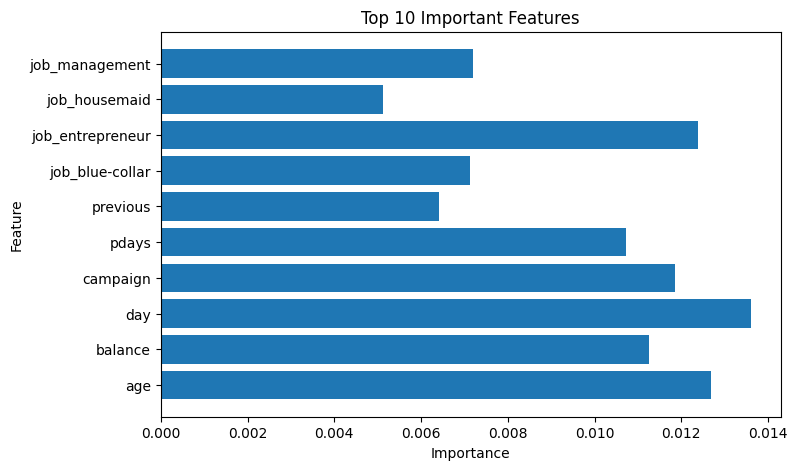

In [141]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10['Feature'],
    top10['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')
plt.title('Top 10 Important Features')

plt.show()